## Imports

In [1]:
from pathlib import Path
import zipfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import random
from shapely.geometry import LineString, Polygon, Point, MultiPolygon
import numpy as np
import networkx as nx
from itertools import combinations
import osmnx as ox
import tobler
from collections import defaultdict
import pickle
import sys
import math 
import os

sys.path.append(str(Path.cwd().parent))

from src import preprocessing
from src import algorithms
from src import visualizations


### Output folder setup

This cell defines the current experiment cycle and creates the results folder for that run.

- `version = "01"` sets the current cycle
- `path = f"../Results/Synthetic/Cycle_{version}"` creates `Results/Synthetic/Cycle_01`
- if you want to run cycle 02, change `version = "01"` to `version = "02"` and rerun the notebook

Later in the notebook, the pickle/plot save lines are currently commented out. Once you want to store results for this cycle, uncomment those lines.

To run 10 cycles, either:
- change `version` manually for each cycle and run the notebook 10 times, or
- refactor the notebook to loop over `version` values automatically

In [2]:
version = "01"

path = f"../Results/Synthetic/Cycle_{version}"
os.makedirs(path, exist_ok=True)

## Parameters for creating the map of copenhagen

In [3]:
# parameters of the grid
resolution = 8

prompt = "Copenhagen Municipality, Denmark" 

prompt_2 = "Frederiksberg Municipality, Denmark" 

prompt_3 = "Tårnby Municipality, Denmark"

proj_crs = "EPSG:2062"

## Grid creation with function from src/preprocessing.py

In [4]:
grid, points, my_polygon = preprocessing.Create_grid_1(resolution, prompt, proj_crs, prompt_2, prompt_3, return_points=True)

/Users/Jev/Desktop/Genetic-algorithms-metro-optimization/.venv/lib/python3.12/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


### Evaluate the grid to see if it looks as expected.

Text(0.5, 1.0, 'Grid over Copenhagne DK.')

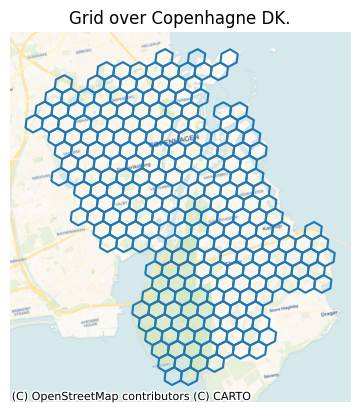

In [5]:
fig, ax = plt.subplots(1,1)
grid.boundary.plot(ax=ax)
cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager, crs = grid.crs)
ax.set_axis_off()
ax.set_title("Grid over Copenhagne DK.")

### Additional visualisation of grid with study area boundaries

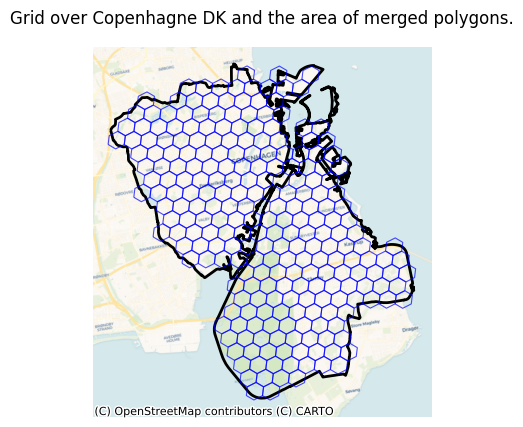

In [6]:
fig, ax = plt.subplots(1,1)
## Plot polygon boundary
my_polygon.boundary.plot(ax=ax, linewidth=2, color="black") # merged boundaries

## Plot grid on top
grid.boundary.plot(ax=ax, linewidth=0.8, color="blue", alpha=0.7)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager, crs = grid.crs)
ax.set_axis_off()
ax.set_title("Grid over Copenhagne DK and the area of merged polygons.")

plt.show()

## Create the OD matrix - creating the pair list and random weight assigned to this pair
#### If data isnt created or new travel data needs to be generated, use the following line to create the OD matrix and save it as a CSV. 


In [7]:
# od_df_tocsv = preprocessing.generate_trip_weight(points, 10, 380)
# od_df_tocsv.to_csv("../data/synthetic_od_data_matrix.csv", index=False)

#### If you already have the CSV, you can skip this step and directly load it with pd.read_csv() as shown in the next cell.

In [8]:
od_df = pd.read_csv("../data/synthetic_od_data_matrix.csv")

## Calculate weight for each hexagon based on previuoslyu created OD matrix and extract total demand

In [9]:
## Calculating the weights for each point based on the OD matrix
pointes_weighted = preprocessing.create_weights(points, od_df)

## Finding total system demand
total_demand = od_df["weight"].sum()

#### Precompute symmetric OD pair weights for faster scoring. This aggregates od_df demand into a dictionary keyed by unordered origin-destination pairs

In [10]:
## Optimized version of calc_score, so time is decreased
pair_weights = defaultdict(float)
for row in od_df.itertuples():
    o, d, w = row.o, row.d, row.weight
    key = (min(o, d), max(o, d))
    pair_weights[key] += w

## Find the valid neighbor moves for the GA route-building logic

In [11]:
## Finding the surrounding/connecting hexagons to each hexagon
valid_connections = preprocessing.finding_neighbors(pointes_weighted, grid)


## attach the neighbor list (`vicinity`) to the base grid so each hexagon has valid next moves
possible_neighbors = grid.merge(
    valid_connections[["cell_id", "vicinity"]],
    on="cell_id",
    how="left"
)

### Visulise the demand, so it is assigned weight to hexagons based on origin destination created matrix

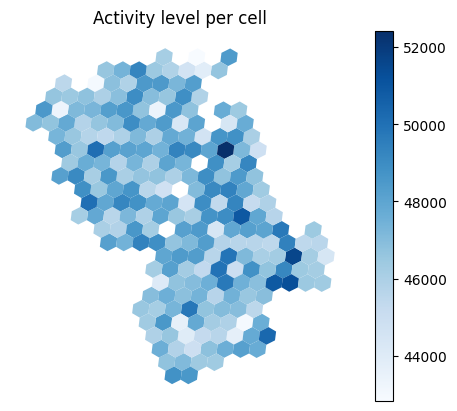

In [12]:
grid_heatmap = grid.merge(
    pointes_weighted[["cell_id", "weight"]],
    on="cell_id",
    how="left"
)

grid_heatmap["weight_int"] = grid_heatmap["weight"].astype(int)

fig, ax = plt.subplots(1,1)
grid_heatmap.plot(
    ax=ax,
    column="weight_int",
    cmap = "Blues",
    legend=True
)
ax.set_axis_off()
ax.set_title("Activity level per cell");

## The Genetic algorithm section

### Set the parameters

In [13]:
# parameters of metro lines
max_routes = 4
max_stops = 17
min_stops = 6 # Becuase existing network have a line of 6 unique stations, M1 part

# parameters of GA algorithms
total_kids = 40
num_of_generations = 20

# parameters for selecting parents later
top_performers = 3
random_performers = 3
sample_size = 3
number_of_parents = 10

### Creation of initial population, defined as list of accepted_kids

In [14]:
# Creating initial population of kids
accepted_kids = []

while len(accepted_kids) < total_kids:
    all_routes = {}
    potential_start = pointes_weighted["cell_id"].tolist()

    routes = 0

    while routes < max_routes:
        if not potential_start:
            break

        route_current = []
        start_node = random.choice(potential_start)
        route_current.append(start_node)
        has_reversed = False

        while len(route_current) < max_stops:

            if random.random() < 0.05 and len(route_current) >= min_stops:  # 5% chance to break
                break

            curr_node = route_current[-1]

            if curr_node in potential_start:
                potential_start.remove(curr_node)

            # filter out nodes already in this route
            vicinity_current = valid_connections.loc[valid_connections.cell_id==curr_node, "vicinity"].values[0]
            poss_neighbors = [n for n in vicinity_current if n not in route_current]

            # find the possible neighbors and their weights
            neighbor_nodes, neighbor_weights = algorithms.TriangleCheck(poss_neighbors, valid_connections, route_current)

            # dead-end handling
            route_current, restart, has_reversed = algorithms.deadend_handeling(neighbor_nodes, route_current, min_stops, has_reversed)

            if restart:
                continue

            if not neighbor_nodes:
                break

            next_node = random.choices(neighbor_nodes, weights=neighbor_weights, k=1)[0]

            route_current.append(next_node)        

        if len(route_current) >= min_stops:
            all_routes[routes] = route_current
            routes += 1
        else:
            continue
                
    G = nx.Graph()
    
    for route_id, route in all_routes.items():
        if not isinstance(route_id, int):
            continue

        for u, v in zip(route[:-1], route[1:]):
            G.add_edge(u, v, route=route_id)
            
    if G.number_of_nodes() == 0:
        continue
            
    is_one_component = nx.is_connected(G)

    ## If it is one componnet, then calculate the demand score and add it to the accepted kids
    if is_one_component: 
        (all_routes["Score as %"], all_routes["AVG_Shortest Path"], all_routes["Average transfers"]) = \
            algorithms.cal_scoreV2(G, od_df, valid_connections, pair_weights)
        all_routes["Number of edges"] = G.number_of_edges()
        all_routes["Number of nodes"] = G.number_of_nodes()
        accepted_kids.append(all_routes)
    else:
        continue

### Return any kid from the initial popualtion by defining its identifier in a square brackets.

In [15]:
# accepted_kids[6]

### Visualise the kids, the ids can be specified 

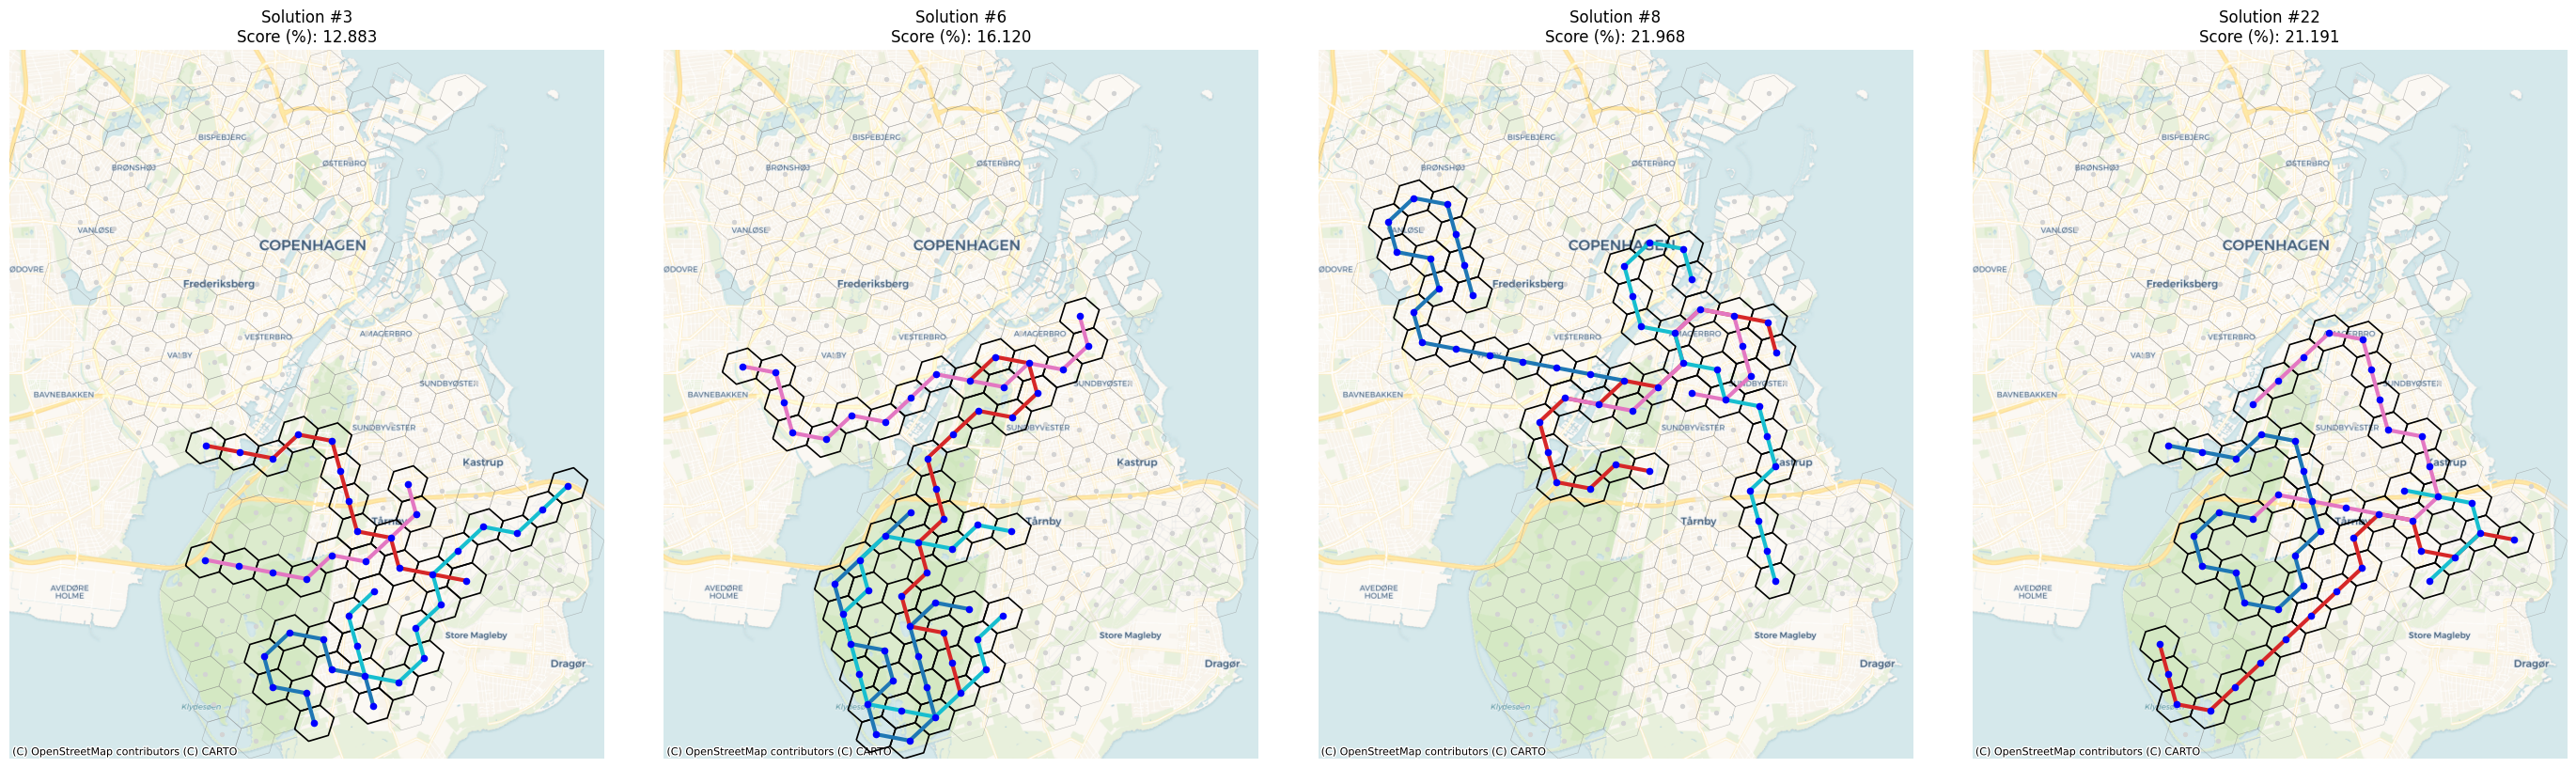

In [16]:
# -------- REPROJECT FOR PLOTTING --------
grid_plot = grid.to_crs(epsg=3857)
points_plot = pointes_weighted.to_crs(epsg=3857)

# -------- SELECT SUBSET --------
selected_indices = [3, 6, 8, 22]   # choose accepted_kids indices here
max_cols = 4

selected_solutions = [
    (i, accepted_kids[i])
    for i in selected_indices
    if 0 <= i < len(accepted_kids)
]

n = len(selected_solutions)

if n == 0:
    print("No valid accepted_kids indices selected.")

else:
    ncols = min(max_cols, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(7 * ncols, 8 * nrows),
        sharex=True,
        sharey=True
    )

    axes = np.atleast_1d(axes).ravel()

    for plot_idx, (solution_idx, solution_dict) in enumerate(selected_solutions):
        ax = axes[plot_idx]

        score = solution_dict.get("Score as %", None)
        edges_gdf = visualizations.build_edges_gdf(solution_dict, points_plot)

        used_nodes = []
        for k, v in solution_dict.items():
            if isinstance(v, (list, tuple)):
                used_nodes.extend(v)

        used_nodes = list(set(used_nodes))

        used_points = points_plot[
            points_plot["cell_id"].isin(used_nodes)
        ]

        used_hex = grid_plot[
            grid_plot["cell_id"].isin(used_nodes)
        ] if "cell_id" in grid_plot.columns else None

        ax.set_xlim(grid_plot.total_bounds[0], grid_plot.total_bounds[2])
        ax.set_ylim(grid_plot.total_bounds[1], grid_plot.total_bounds[3])

        cx.add_basemap(
            ax=ax,
            source=cx.providers.CartoDB.Voyager,
            crs=grid_plot.crs
        )

        grid_plot.boundary.plot(
            ax=ax,
            color="gray",
            linewidth=0.4,
            alpha=0.5,
            zorder=2
        )

        if used_hex is not None and not used_hex.empty:
            used_hex.boundary.plot(
                ax=ax,
                color="black",
                linewidth=1.2,
                zorder=3
            )

        if not edges_gdf.empty:
            edges_gdf.plot(
                ax=ax,
                column="route_id",
                categorical=True,
                legend=False,
                linewidth=3,
                zorder=4
            )

        points_plot.plot(
            ax=ax,
            color="lightgray",
            markersize=8,
            zorder=5
        )

        if not used_points.empty:
            used_points.plot(
                ax=ax,
                color="blue",
                markersize=20,
                zorder=6
            )

        if isinstance(score, (int, float)):
            ax.set_title(f"Solution #{solution_idx}\nScore (%): {score:.3f}")
        elif score is not None:
            ax.set_title(f"Solution #{solution_idx}\nScore (%): {score}")
        else:
            ax.set_title(f"Solution #{solution_idx}")

        ax.set_axis_off()
        ax.set_aspect("equal")

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

### Visualise correlation between demand score and amount of edges

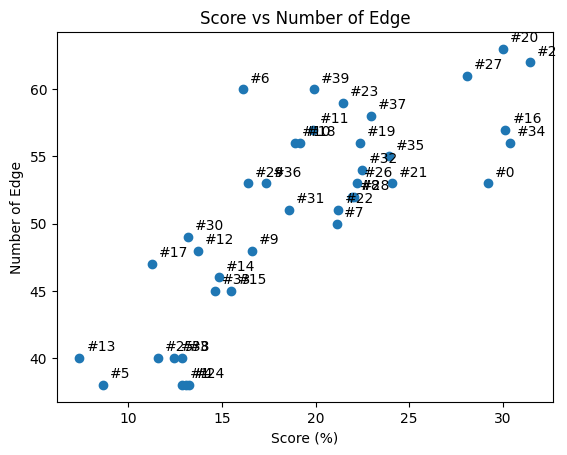

In [17]:
x = [d["Score as %"] for d in accepted_kids]
y = [d["Number of edges"] for d in accepted_kids]

for i in range(len(x)):
    plt.annotate(f"#{i}",
                 (x[i], y[i]),
                 textcoords="offset points",
                 xytext=(5,5),
                 ha='left')

plt.scatter(x, y)
plt.xlabel("Score (%)")
plt.ylabel("Number of Edge")
plt.title("Score vs Number of Edge")
plt.show()

## Running GA

### Launching the parent selection function to pre-identify 10 kids out of 40 as parents

In [18]:
parents_of_new_gen = algorithms.select_parents(accepted_kids, top_performers, random_performers, sample_size, number_of_parents)

### This section creates multiple generations of transport networks using crossover operations 

For each generated network:
- Routes are converted into a graph structure
- Connectivity is validated using NetworkX
- evaluation metrics are calculated
- Graph statistics (edges/nodes) are stored

The final generations can be exported as a  `.pkl` dataset for later analysis

In [19]:
generations = {}
gen_id = 1

OG_pop = {index: value for index, value in enumerate(accepted_kids)}
OG_pop = algorithms.normalize_generation(OG_pop)
generations[0] = OG_pop

while len(generations) < num_of_generations:
    kids = {}
    kid_id = 0
    while len(kids) < total_kids:
        new_kid = algorithms.crossover(parents_of_new_gen, possible_neighbors, 0.1, valid_connections)
               
        G = nx.Graph() 
        for route_id, route in new_kid.items():
            if not isinstance(route_id, int):
                continue

            for u, v in zip(route[:-1], route[1:]):
                G.add_edge(u, v, route=route_id)

        is_one_component = nx.is_connected(G)
        
        if is_one_component: # false then skip
            kids[kid_id] = new_kid
            (kids[kid_id]["Score as %"], kids[kid_id]["AVG_Shortest Path"], kids[kid_id]["Average transfers"]) \
            = algorithms.cal_scoreV2(G, od_df, valid_connections, pair_weights)
            kids[kid_id]["Number of edges"] = G.number_of_edges()
            kids[kid_id]["Number of nodes"] = G.number_of_nodes()
            kid_id += 1

    kids = algorithms.normalize_generation(kids)
    generations[gen_id] = kids
    gen_id += 1

# UNCOMMENT THIS PART TO SAVE THE GENERATIONS DATA AS PICKLE FILE

# with open(f"../Results/Synthetic/Cycle_{version}/{version}_gen_data.pkl", "wb") as f:
    # pickle.dump(generations, f)

#### Generation Validation

In [20]:
print(len(generations)) # 20 generations
print(len(generations[0])) # 40 kids
print(len(generations[19][2])) # 14 values - 4 lines and 10 metadata values

20
40
14


## Performance visualisation with Demand coverage % vs Edge amount

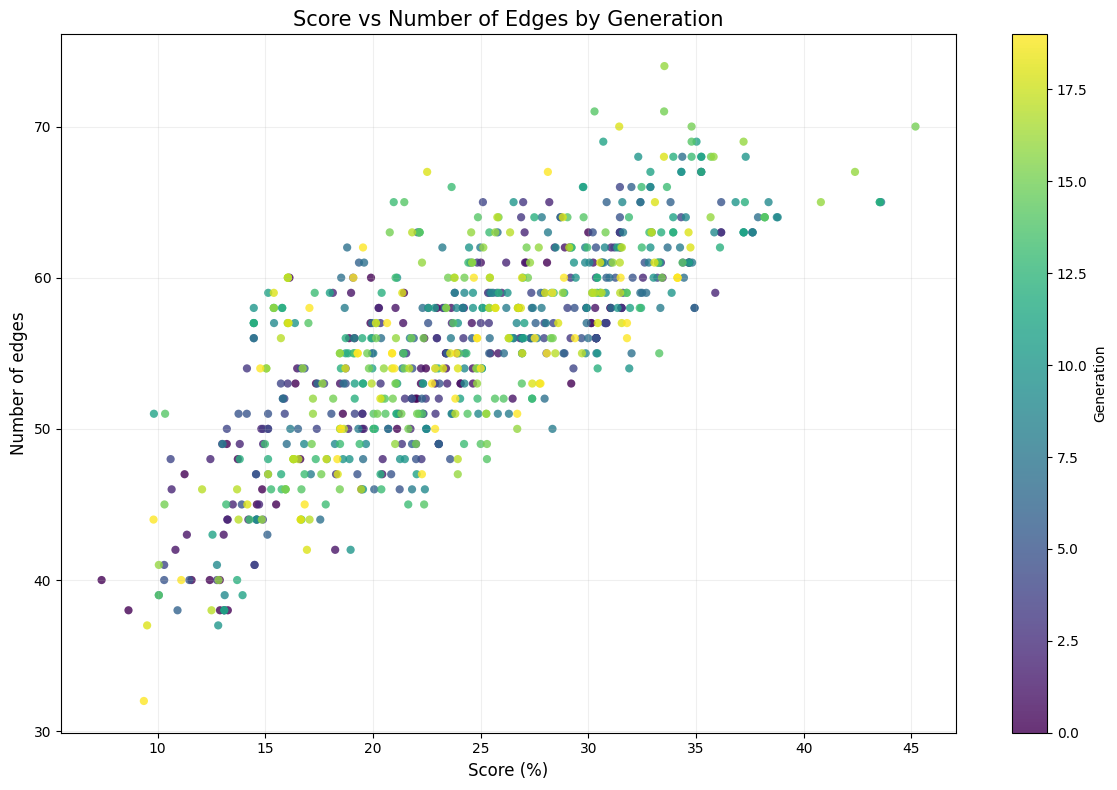

In [21]:
# Collect all data first
x = []
y = []
gen_vals = []

for gen_name, kids_dict in generations.items():
    for kid_info in kids_dict.values():
        x.append(kid_info["Score as %"])
        y.append(kid_info["Number of edges"])
        gen_vals.append(int(gen_name))   # assumes generation names are numeric strings

# Create larger figure
plt.figure(figsize=(12, 8))

# Scatter plot with continuous colormap
scatter = plt.scatter(
    x,
    y,
    c=gen_vals,          # color by generation
    cmap="viridis",      # continuous colormap
    s=35,                # smaller points
    alpha=0.8,
    edgecolors="none"
)

# Labels and title
plt.xlabel("Score (%)", fontsize=12)
plt.ylabel("Number of edges", fontsize=12)
plt.title("Score vs Number of Edges by Generation", fontsize=15)

# Add colorbar instead of legend
cbar = plt.colorbar(scatter)
cbar.set_label("Generation")

# Optional styling
plt.grid(True, alpha=0.2)
plt.tight_layout()

# UNCOMMENT THIS PART TO SAVE THIS PLOT

# plt.savefig(f"../Results/Synthetic/Cycle_{version}/{version}_generation_plot_1.png", dpi=300, bbox_inches="tight")

plt.show()

## Performance visualisation with Demand coverage % acroos generations 

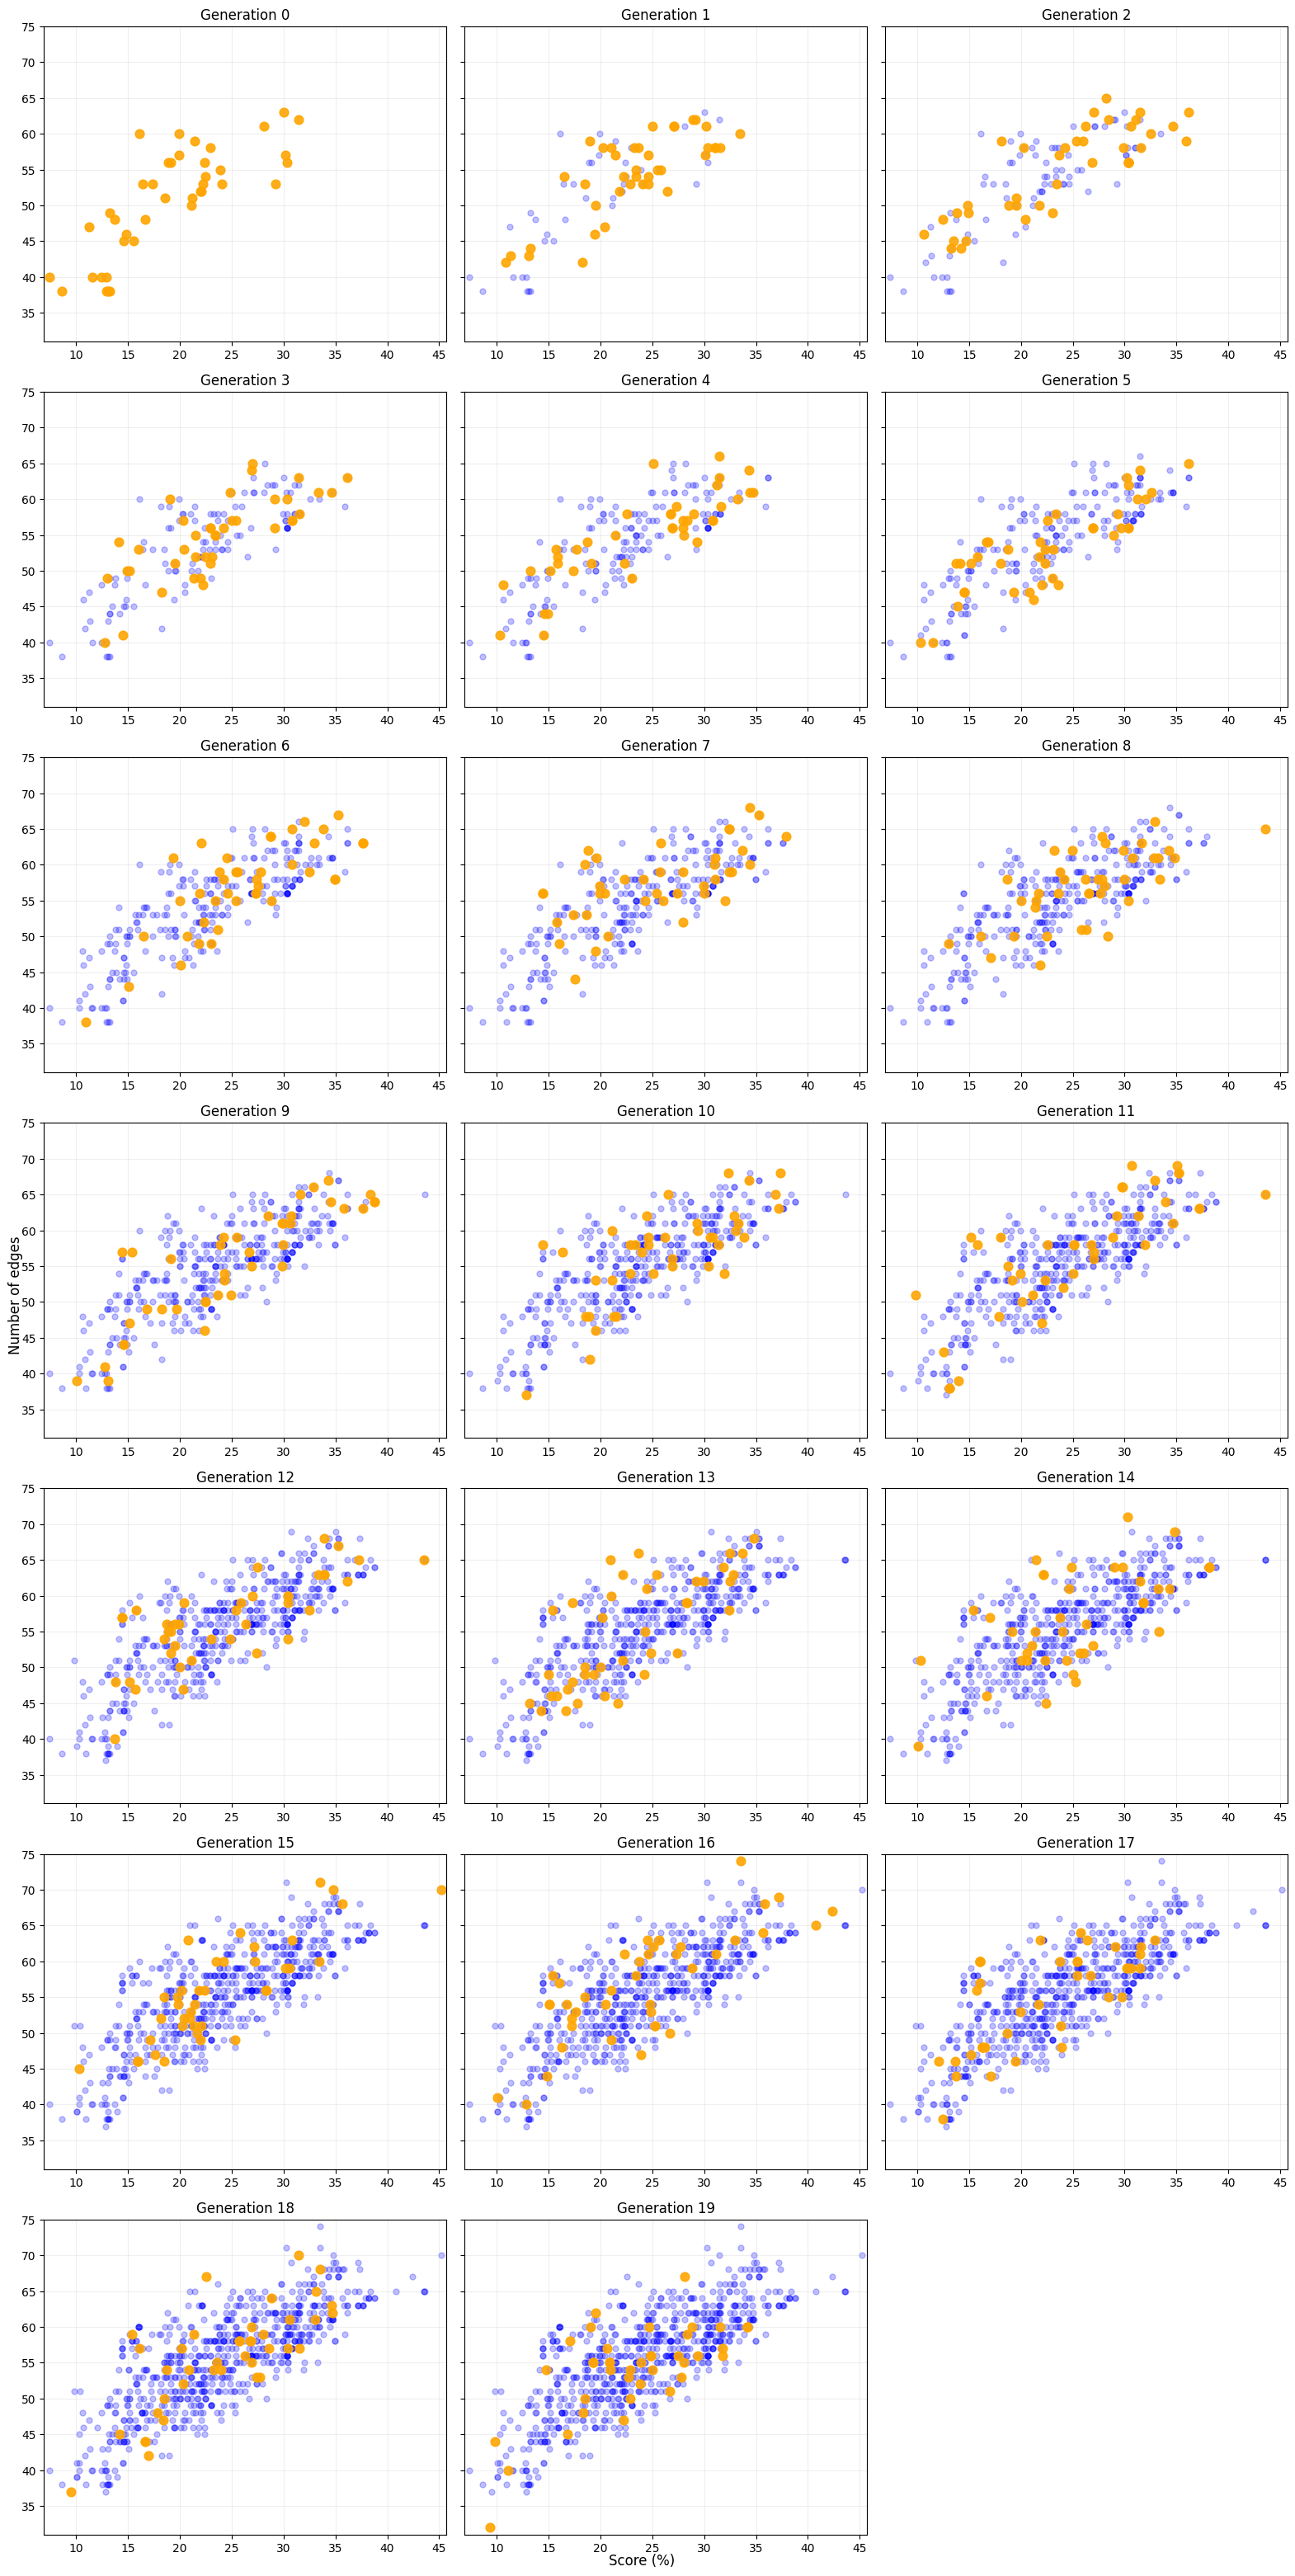

In [22]:
# Flatten data by generation
gen_data = {}

for gen_name, kids_dict in generations.items():
    gen = int(gen_name)
    gen_data[gen] = {
        "x": [kid_info["Score as %"] for kid_info in kids_dict.values()],
        "y": [kid_info["Number of edges"] for kid_info in kids_dict.values()],
    }

gens = sorted(gen_data.keys())

# Shared axis limits for easier comparison
all_x = [v for gen in gens for v in gen_data[gen]["x"]]
all_y = [v for gen in gens for v in gen_data[gen]["y"]]

x_pad = 0.5
y_pad = 1

ncols = 3
nrows = math.ceil(len(gens) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 4.5 * nrows),
    sharex=False,
    sharey=True
)

axes = axes.flatten()

for ax, gen in zip(axes, gens):
    # Previous generations
    prev_x = [v for g in gens if g < gen for v in gen_data[g]["x"]]
    prev_y = [v for g in gens if g < gen for v in gen_data[g]["y"]]

    if prev_x:
        ax.scatter(
            prev_x,
            prev_y,
            s=25,
            alpha=0.25,
            label="Previous generations",
            color="blue"
        )

    # Current generation highlighted
    ax.scatter(
        gen_data[gen]["x"],
        gen_data[gen]["y"],
        s=60,
        alpha=0.9,
        label=f"Generation {gen}",
        color="orange"
    )

    ax.set_title(f"Generation {gen}")
    ax.grid(True, alpha=0.2)
    ax.set_xlim(min(all_x) - x_pad, max(all_x) + x_pad)
    ax.set_ylim(min(all_y) - y_pad, max(all_y) + y_pad)

# Remove empty subplot slots
for ax in axes[len(gens):]:
    ax.remove()

fig.supxlabel("Score (%)")
fig.supylabel("Number of edges")


plt.tight_layout()

# UNCOMMENT THIS PART TO SAVE THIS PLOT

# plt.savefig(f"../Results/Synthetic/Cycle_{version}/{version}_generation_plot_2.png", dpi=300, bbox_inches="tight")

plt.show()

## Extract average demand score (%) per generation

In [23]:
# Calcuulate the average score for each genration
for i in range(len(generations)):
    generation_total = 0
    for j in range(len(generations[i])):
        generation_total += generations[i][j]["Score as %"].sum()
    # print(f"Generation {i}: {generation_total}")
    print(f"Generation {i} average: {generation_total / len(generations[i])}")
   

Generation 0 average: 19.080320334973912
Generation 1 average: 23.34946694309874
Generation 2 average: 23.96218718360997
Generation 3 average: 23.465032889782968
Generation 4 average: 23.936807724238484
Generation 5 average: 22.695555783944744
Generation 6 average: 26.28048474041365
Generation 7 average: 25.485936413665932
Generation 8 average: 26.422283997441582
Generation 9 average: 25.195145813747796
Generation 10 average: 26.189279631498096
Generation 11 average: 25.296034131779635
Generation 12 average: 24.6761278919202
Generation 13 average: 23.00578540551313
Generation 14 average: 25.34972109853579
Generation 15 average: 23.688150148389216
Generation 16 average: 23.97246295834493
Generation 17 average: 21.98962058062562
Generation 18 average: 24.336746476517014
Generation 19 average: 23.411760240733795


## Extract average of MO score


In [24]:
# Calcuulate the average score for each genration
for i in range(len(generations)):
    generation_total = 0
    for j in range(len(generations[i])):
        generation_total += generations[i][j]["Final score"].sum()
    # print(f"Generation {i}: {generation_total}")
    print(f"Generation {i} average: {generation_total / len(generations[i])}")

Generation 0 average: 0.0973163381150796
Generation 1 average: 0.1057096318381052
Generation 2 average: 0.11852145701669241
Generation 3 average: 0.10491676200067757
Generation 4 average: 0.11533230102149124
Generation 5 average: 0.1144197765129531
Generation 6 average: 0.11840169748059451
Generation 7 average: 0.1222961454073784
Generation 8 average: 0.14369417678024632
Generation 9 average: 0.11342142806278599
Generation 10 average: 0.12854207509932528
Generation 11 average: 0.13180144385773235
Generation 12 average: 0.13465960057691825
Generation 13 average: 0.1125418763476943
Generation 14 average: 0.11869202402411219
Generation 15 average: 0.13758345066558886
Generation 16 average: 0.11665747386000185
Generation 17 average: 0.1129839291853912
Generation 18 average: 0.11669354350858599
Generation 19 average: 0.09743305666662308


# Extract the best performer of each generation together witH its ID - Demand coverage %

In [25]:
# Extract the best performer of generation and its id
for i in range(len(generations)):
    generation_total = 0
    best_performer = sorted(generations[i].values(), key=lambda x: x["Score as %"], reverse=True)[0]
    best_performer_id = [k for k, v in generations[i].items() if v == best_performer][0]
    print(f"Generation {i}: {best_performer['Score as %']}, ID: {best_performer_id}")

Generation 0: 31.46757331380084, ID: 2
Generation 1: 33.448733639884956, ID: 16
Generation 2: 36.16870982248595, ID: 33
Generation 3: 36.16870982248595, ID: 3
Generation 4: 34.68951300583714, ID: 4
Generation 5: 36.171387888671745, ID: 25
Generation 6: 37.622325890048344, ID: 17
Generation 7: 37.87995933513007, ID: 4
Generation 8: 43.59903923506083, ID: 9
Generation 9: 38.796362281837595, ID: 12
Generation 10: 37.3096703578766, ID: 24
Generation 11: 43.537148082104636, ID: 3
Generation 12: 43.537148082104636, ID: 3
Generation 13: 34.79620090226484, ID: 30
Generation 14: 38.19176275533361, ID: 2
Generation 15: 45.1952188519165, ID: 16
Generation 16: 42.38561440229215, ID: 2
Generation 17: 32.940266255427, ID: 1
Generation 18: 34.74376993115978, ID: 5
Generation 19: 34.14273536289014, ID: 6


# Extract the best performer of each generation together wit its ID - MO score 

In [26]:
for i in range(len(generations)):
    generation_total = 0
    best_performer = sorted(generations[i].values(), key=lambda x: x["Final score"], reverse=True)[0]
    best_performer_id = [k for k, v in generations[i].items() if v == best_performer][0]
    print(f"Generation {i}: {best_performer['Final score']}, ID: {best_performer_id}")

Generation 0: 0.13368420587575494, ID: 22
Generation 1: 0.14335226593967196, ID: 1
Generation 2: 0.17065179456861304, ID: 12
Generation 3: 0.15092809388575595, ID: 15
Generation 4: 0.16334285639612828, ID: 8
Generation 5: 0.15724385907850022, ID: 8
Generation 6: 0.16247749433483977, ID: 19
Generation 7: 0.20226216678621797, ID: 35
Generation 8: 0.19975841321694124, ID: 38
Generation 9: 0.1586680581926346, ID: 35
Generation 10: 0.18602187237841486, ID: 36
Generation 11: 0.17255973676416253, ID: 28
Generation 12: 0.18169647086435162, ID: 38
Generation 13: 0.165517317928616, ID: 3
Generation 14: 0.1778915816655539, ID: 0
Generation 15: 0.1934755198340189, ID: 9
Generation 16: 0.16782709744247087, ID: 38
Generation 17: 0.17063338732547184, ID: 31
Generation 18: 0.17158371047057464, ID: 31
Generation 19: 0.12038347104288083, ID: 28


## Extracting the average length of the metro network, interpreted as edges
### For operator's cost approximation

### Average amount of edges

In [27]:
# Calculate the average length of metro network for each generation

for i in range(len(generations)):
    generation_length = 0
    for j in range(len(generations[i])):
        generation_length += generations[i][j]["Number of edges"]
    # print(f"Generation {i}: {generation_length}")
    print(f"Generation {i} average: {generation_length / len(generations[i])}")

# Define the best solution's generation and kid id to get the amount of edges for it

best_sol_amount_of_edges = generations[19][15]["Number of edges"]

print(f"The best solution based on score has {best_sol_amount_of_edges} edges")

Generation 0 average: 50.775
Generation 1 average: 54.4
Generation 2 average: 54.925
Generation 3 average: 54.775
Generation 4 average: 54.85
Generation 5 average: 53.175
Generation 6 average: 57.025
Generation 7 average: 57.5
Generation 8 average: 56.95
Generation 9 average: 55.375
Generation 10 average: 56.8
Generation 11 average: 56.925
Generation 12 average: 56.575
Generation 13 average: 55.075
Generation 14 average: 56.75
Generation 15 average: 55.55
Generation 16 average: 56.675
Generation 17 average: 54.8
Generation 18 average: 55.8
Generation 19 average: 54.275
The best solution based on score has 48 edges


### Average amount of nodes

In [28]:
# Extracting the average amount of nodes as well 

for i in range(len(generations)):
    generation_nodes = 0
    for j in range(len(generations[i])):
        generation_nodes += generations[i][j]["Number of nodes"]
    # print(f"Generation {i}: {generation_nodes}")
    print(f"Generation {i} average: {generation_nodes / len(generations[i])}")

# Define the best solution's generation and kid id to get the amount of edges for it

best_sol_amount_of_edges = generations[19][15]["Number of nodes"]

print(f"The best solution based on score has {best_sol_amount_of_edges} nodes")

Generation 0 average: 49.6
Generation 1 average: 53.1
Generation 2 average: 53.775
Generation 3 average: 53.275
Generation 4 average: 53.625
Generation 5 average: 52.175
Generation 6 average: 55.175
Generation 7 average: 55.8
Generation 8 average: 55.875
Generation 9 average: 54.525
Generation 10 average: 55.3
Generation 11 average: 54.875
Generation 12 average: 54.825
Generation 13 average: 53.225
Generation 14 average: 55.0
Generation 15 average: 54.3
Generation 16 average: 54.525
Generation 17 average: 52.65
Generation 18 average: 53.925
Generation 19 average: 52.9
The best solution based on score has 49 nodes


## Results for the average shortest path 

In [29]:
for i in range(len(generations)):

    generation_short = 0

    for j in range(len(generations[i])):

        generation_short += generations[i][j]["AVG_Shortest Path"]

    avg_shortest = generation_short / len(generations[i])

    print(f"Generation {i} average: {avg_shortest}")
    
# Define the best solution's generation and kid id to get the amount of edges for it
    
best_sol_shortest_path = generations[19][15]["AVG_Shortest Path"]

print(f"The best solution based on score has an average shortest path of: {best_sol_shortest_path}")

Generation 0 average: 9.692157416917173
Generation 1 average: 10.51177300307473
Generation 2 average: 10.320898034421354
Generation 3 average: 10.557069978037008
Generation 4 average: 10.678002875833487
Generation 5 average: 10.048719035631851
Generation 6 average: 10.848319183637194
Generation 7 average: 10.742949733391988
Generation 8 average: 11.24342609822926
Generation 9 average: 10.94038615192827
Generation 10 average: 10.886836802568672
Generation 11 average: 10.603511896563594
Generation 12 average: 10.806100617288163
Generation 13 average: 10.203776452183282
Generation 14 average: 10.58785414293976
Generation 15 average: 10.852243818040602
Generation 16 average: 10.352592616699937
Generation 17 average: 10.709052240889932
Generation 18 average: 10.290506726606411
Generation 19 average: 10.423387470465443
The best solution based on score has an average shortest path of: 11.068027210884354


## Results for the average amount of transfers

In [30]:
# Extracting the average amount of transfers as well

for i in range(len(generations)):

    total_transfers = 0
    count = 0

    for j in range(len(generations[i])):

        total_transfers += generations[i][j]["Average transfers"]
        count += 1

    avg_generation_transfers = total_transfers / count

    print(f"Generation {i}: {avg_generation_transfers}")
    
# Define the best solution's generation and kid id to get the amount of edges for it
    
best_sol_shortest_path = generations[19][15]["Average transfers"]

print(f"The best solution based on score has an average amount of transfer equal to {best_sol_shortest_path}")

Generation 0: 1.4685461506178525
Generation 1: 1.5341611676422917
Generation 2: 1.516771782668595
Generation 3: 1.388603866399049
Generation 4: 1.429449366241594
Generation 5: 1.6151807309565431
Generation 6: 1.4702143145210806
Generation 7: 1.5753297010660121
Generation 8: 1.3981436413106683
Generation 9: 1.3426113925956273
Generation 10: 1.4051423741627977
Generation 11: 1.4819642358223506
Generation 12: 1.4930574142067456
Generation 13: 1.4774159628117076
Generation 14: 1.422736595599008
Generation 15: 1.5026082729394292
Generation 16: 1.4814116667950588
Generation 17: 1.475159744733805
Generation 18: 1.573355136832823
Generation 19: 1.4824704157297894
The best solution based on score has an average amount of transfer equal to 1.0025510204081634
